# RSVP PDE Field Simulator Notebook

This notebook implements a simple **PDE-style simulator** for an RSVP-inspired
field triple on a 2D grid:

- Scalar field $\Phi(x,y,t)$ ("potential / density")
- Vector field $\mathbf{v}(x,y,t)$ ("flow")
- Entropy field $S(x,y,t)$ ("disorder / lamphrodynamic cost")

The evolution rules are intentionally simple and phenomenological, designed for
experimentation and visualization rather than physical fidelity:

- $\Phi$ diffuses and is advected by $\mathbf{v}$
- $\mathbf{v}$ follows a smoothed gradient flow of $\Phi$ with damping
- $S$ increases with local gradients and vorticity of $\mathbf{v}$ and diffuses

You can treat this as a sandbox for:

- Testing lamphrodynamic intuitions
- Exploring stability and pattern formation
- Producing example figures for the monograph

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('Imports successful.')

Imports successful.


In [2]:
# Simulation config
nx, ny = 64, 64         # grid size
dx = dy = 1.0
dt = 0.05               # time step

# PDE coefficients
D_phi = 0.2             # diffusion for Φ
D_S   = 0.1             # diffusion for S
beta_v = 1.0            # strength of -∇Φ in v dynamics
gamma_v = 0.5           # damping for v
nu_v = 0.1              # viscosity (smoothing) for v

c_gradPhi = 0.5         # weight: |∇Φ|^2 contribution to S
c_vort    = 0.3         # weight: vorticity contribution
c_div     = 0.2         # weight: divergence contribution

# ------------------------------------------------------------------
# Helper functions: periodic finite differences
# ------------------------------------------------------------------

def laplacian(field):
    """2D Laplacian with periodic boundary conditions."""
    return (
        np.roll(field, 1, axis=0) +
        np.roll(field, -1, axis=0) +
        np.roll(field, 1, axis=1) +
        np.roll(field, -1, axis=1) -
        4.0 * field
    ) / (dx * dy)

def grad(field):
    """Gradient of scalar field -> (gx, gy), periodic BC."""
    gx = (np.roll(field, -1, axis=0) - np.roll(field, 1, axis=0)) / (2 * dx)
    gy = (np.roll(field, -1, axis=1) - np.roll(field, 1, axis=1)) / (2 * dy)
    return gx, gy

def divergence(vx, vy):
    """Divergence of vector field v = (vx, vy)."""
    dvx_dx = (np.roll(vx, -1, axis=0) - np.roll(vx, 1, axis=0)) / (2 * dx)
    dvy_dy = (np.roll(vy, -1, axis=1) - np.roll(vy, 1, axis=1)) / (2 * dy)
    return dvx_dx + dvy_dy

def curl_z(vx, vy):
    """z-component of curl in 2D: ∂v_y/∂x - ∂v_x/∂y."""
    dvy_dx = (np.roll(vy, -1, axis=0) - np.roll(vy, 1, axis=0)) / (2 * dx)
    dvx_dy = (np.roll(vx, -1, axis=1) - np.roll(vx, 1, axis=1)) / (2 * dy)
    return dvy_dx - dvx_dy

print("Config and helpers defined.")


Config and helpers defined.


In [3]:
# Coordinate grid (for nicer initial conditions if desired)
x = np.linspace(-2, 2, nx)
y = np.linspace(-2, 2, ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# Scalar field Φ: a couple of Gaussian blobs
Phi = np.exp(-((X+0.7)**2 + (Y+0.3)**2) / 0.3) \
    + 0.7 * np.exp(-((X-0.6)**2 + (Y-0.8)**2) / 0.4)

# Vector field v: small random flow to start
vx = 0.1 * np.random.randn(nx, ny)
vy = 0.1 * np.random.randn(nx, ny)

# Entropy field S: start near 0
S = 0.0 * np.ones((nx, ny), dtype=np.float64)

print("Fields initialized: Φ, v, S.")


Fields initialized: Φ, v, S.


In [4]:
def step_rsvp_pde(Phi, vx, vy, S):
    """
    One explicit Euler step of the RSVP toy PDE system.
    Returns updated (Phi_new, vx_new, vy_new, S_new).
    """
    # --- Φ dynamics: diffusion + advection by v ---
    lap_Phi = laplacian(Phi)
    gx_phi, gy_phi = grad(Phi)

    # advection term: - v · ∇Φ
    adv_Phi = -(vx * gx_phi + vy * gy_phi)

    Phi_new = Phi + dt * (D_phi * lap_Phi + adv_Phi)

    # --- v dynamics: gradient flow of Φ + damping + diffusion ---
    gx_phi, gy_phi = grad(Phi)  # reuse fresh grad of old Φ
    lap_vx = laplacian(vx)
    lap_vy = laplacian(vy)

    vx_new = vx + dt * (-beta_v * gx_phi - gamma_v * vx + nu_v * lap_vx)
    vy_new = vy + dt * (-beta_v * gy_phi - gamma_v * vy + nu_v * lap_vy)

    # --- S dynamics: reacts to gradients, vorticity, divergence + diffuses ---
    curl_v = curl_z(vx, vy)
    div_v  = divergence(vx, vy)

    gradPhi_sq = gx_phi**2 + gy_phi**2
    vort_sq    = curl_v**2
    div_sq     = div_v**2

    production = c_gradPhi * gradPhi_sq + c_vort * vort_sq + c_div * div_sq
    lap_S = laplacian(S)

    S_new = S + dt * (D_S * lap_S + production)

    return Phi_new, vx_new, vy_new, S_new

print("Step function defined.")


Step function defined.


Simulation finished.


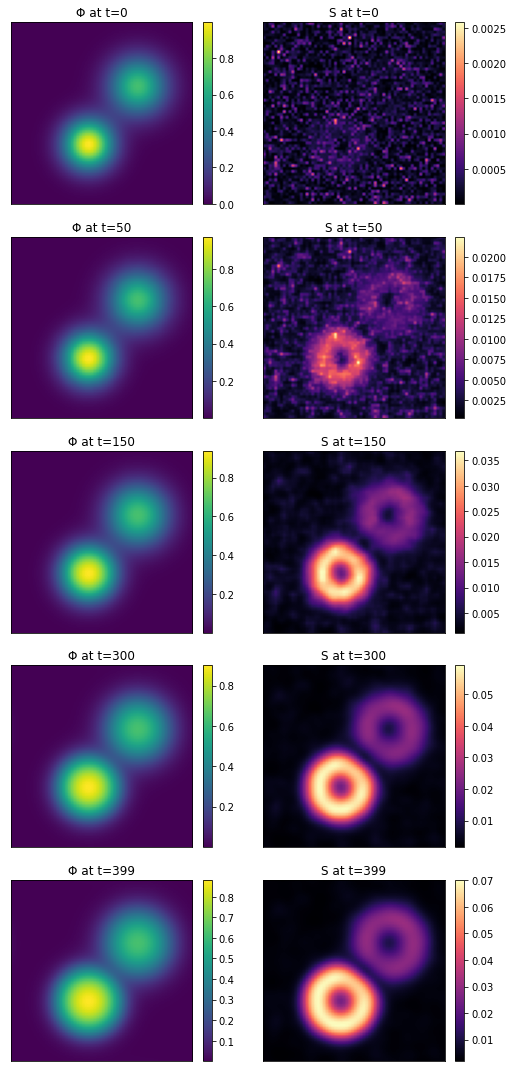

In [5]:
n_steps = 400
snapshots = [0, 50, 150, 300, 399]  # which timesteps to visualize

Phi_hist = {}
S_hist = {}

Phi_curr, vx_curr, vy_curr, S_curr = Phi, vx, vy, S

for t in range(n_steps):
    Phi_curr, vx_curr, vy_curr, S_curr = step_rsvp_pde(Phi_curr, vx_curr, vy_curr, S_curr)

    if t in snapshots:
        Phi_hist[t] = Phi_curr.copy()
        S_hist[t] = S_curr.copy()

print("Simulation finished.")

# --- Plot snapshots ---
fig, axes = plt.subplots(len(snapshots), 2, figsize=(8, 3*len(snapshots)))

for i, t in enumerate(snapshots):
    ax_phi = axes[i, 0]
    ax_S   = axes[i, 1]

    im1 = ax_phi.imshow(Phi_hist[t], origin='lower', cmap='viridis')
    ax_phi.set_title(f"Φ at t={t}")
    ax_phi.set_xticks([]); ax_phi.set_yticks([])
    fig.colorbar(im1, ax=ax_phi, fraction=0.046, pad=0.04)

    im2 = ax_S.imshow(S_hist[t], origin='lower', cmap='magma')
    ax_S.set_title(f"S at t={t}")
    ax_S.set_xticks([]); ax_S.set_yticks([])
    fig.colorbar(im2, ax=ax_S, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


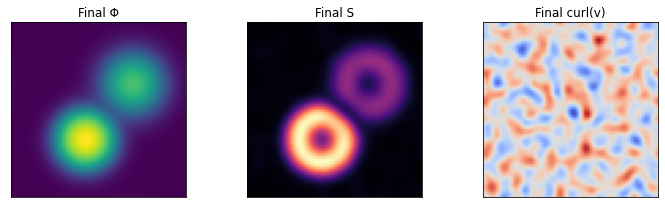

In [6]:
curl_final = curl_z(vx_curr, vy_curr)

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(Phi_curr, origin='lower', cmap='viridis')
plt.title("Final Φ")
plt.xticks([]); plt.yticks([])

plt.subplot(1,3,2)
plt.imshow(S_curr, origin='lower', cmap='magma')
plt.title("Final S")
plt.xticks([]); plt.yticks([])

plt.subplot(1,3,3)
plt.imshow(curl_final, origin='lower', cmap='coolwarm')
plt.title("Final curl(v)")
plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()
